# NB15 — MIMIC-IV External Validation (RQ5)

**Input:**
- `C:/ML PROJECT/DATASETS/mimic-iv-3.1/` — MIMIC-IV v3.1 extracted files
- `data/processed/feature_config.json` — GP_TERMINALS list
- `results/v2_bce/gp_runs/run_14_model.pkl` — canonical GP model (seed=14, c=24)

**Output:**
- `data/processed/mimic_cohort.parquet` — MIMIC-IV sepsis cohort (one row per first ICU stay)
- `data/processed/mimic_features.parquet` — feature matrix aligned to GP_TERMINALS
- `data/processed/mimic_gp_predictions.csv` — GP formula applied zero-shot
- `results/v2_bce/tables/NB15_mimic_metrics.csv` — evaluation metrics vs eICU
- `results/v2_bce/figures/NB15_mimic_calibration.pdf/.png`

---

### Purpose
Apply the canonical GP formula (seed=14, complexity=24, BCE loss) zero-shot to MIMIC-IV v3.1
to assess cross-database generalisability (RQ5, Contribution C1). No retraining is performed —
this is the strongest possible external validity test: the formula is applied exactly as evolved
on eICU-CRD to a different database with different table structure, coding conventions, and
patient population.

### Cohort definition
Adult (age ≥ 18) ICU patients with a sepsis diagnosis, identified via ICD-10-CM codes
A40.x (streptococcal sepsis), A41.x (other sepsis), R65.20 (severe sepsis without shock),
and R65.21 (septic shock). First ICU stay per hospital admission only. Hospital mortality
outcome from `admissions.hospital_expire_flag`. This ICD-code approach is used in published
MIMIC-IV sepsis validation studies (e.g. Fleuren et al. 2021) and is disclosed as a limitation
relative to the clinical Sepsis-3 criteria (suspicion of infection + SOFA ≥ 2 acute change)
applied in the eICU-CRD cohort (NB02).

### Feature window
24-hour window from ICU admission (`intime` to `intime + 24h`), matching NB03. Vitals from
`chartevents`; labs from `labevents`. Aggregation: mean for continuous vitals, max for
lactate_max and platelets (inverted to min), mean for MAP, first recorded for temperature,
heart rate. MNAR indicators computed as in NB03: `pf_ratio_miss=1` if PaO2 absent in window,
`lactate_max_miss=1` if lactate absent.

### Runtime note
- Cell 1: Fast — uses small extracted files only (patients, admissions, icustays, diagnoses_icd)
- Cell 2: Fast — labs from labevents (2.47 GB compressed; filter to cohort stay_ids first)
- Cell 3: Slow — chartevents (3.34 GB compressed; filter to cohort stay_ids first)
- Cell 4: Fast — assemble matrix, apply formula, evaluate

### MIMIC-IV ITEMID reference (confirmed from d_items / d_labitems)
| Feature | Source | ITEMID(s) |
|---|---|---|
| heartrate | chartevents | 220045 |
| temperature (°C) | chartevents | 223762 (°C direct), 223761 (°F→°C) |
| map_mean | chartevents | 220052, 225312 |
| FiO2 | chartevents | 223835 |
| vent | chartevents | 225792 (Invasive Ventilation), 223849 (Ventilator Mode) |
| intubated | chartevents | 225792 (Invasive Ventilation) |
| GCS eye | chartevents | 220739 |
| GCS motor | chartevents | 223901 |
| GCS verbal | chartevents | 223900 |
| bun | labevents | 51006 |
| bilirubin | labevents | 50885 |
| lactate_max | labevents | 50813 |
| platelets_min | labevents | 51265 |
| pao2 (for pf_ratio) | labevents | 50821 |
| age_numeric | patients | anchor_age + (ICU admit year − anchor_year) |


In [1]:
## Cell 1 — Imports, Paths, and Cohort Identification

# Plan:
# Apply inclusion criteria matching eICU-CRD NB02 filters as closely as MIMIC-IV allows:
#
#   eICU F1 → MIMIC F1: Age ≥ 18
#   eICU F2 → MIMIC F2: ICU LOS ≥ 24h  (eICU used 24h, not 4h)
#   eICU F3 → MIMIC F3: Sepsis diagnosis — eICU used APACHE infection dx + SOFA ≥ 2;
#              MIMIC equivalent: ICD-10 codes A40.x, A41.x, R65.20, R65.21
#              (pragmatic equivalent; disclosed as a limitation)
#   eICU F5 → MIMIC F4: First qualifying sepsis stay per patient (deduplication)
#   eICU F6: Hospital size ≥75, ≥8 deaths — MIMIC-IV is single centre (BIDMC);
#             trivially passes (thousands of admissions, hundreds of deaths) → kept all
#
# Outcome: hospital_expire_flag from admissions
# Save cohort to data/processed/mimic_cohort.parquet

from pathlib import Path
import pandas as pd
import numpy as np
import json, pickle, warnings
warnings.filterwarnings('ignore')

_nb_dir  = Path().resolve()
PROJECT  = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
DATA_PROC = PROJECT / 'data' / 'processed'
MIMIC    = Path('C:/ML PROJECT/DATASETS/mimic-iv-3.1')

import sys
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.metrics import compute_ece, compute_metrics, calibration_bins

RESULTS_VERSION = 'v2_bce'
TABLES  = PROJECT / 'results' / RESULTS_VERSION / 'tables'
FIGURES = PROJECT / 'results' / RESULTS_VERSION / 'figures'
RUNS_DIR = PROJECT / 'results' / RESULTS_VERSION / 'gp_runs'

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

with open(DATA_PROC / 'feature_config.json') as f:
    cfg = json.load(f)
GP_TERMINALS = cfg['GP_TERMINALS']
print(f'GP_TERMINALS: {len(GP_TERMINALS)} features')
print(f'MIMIC path: {MIMIC}')
print()

# ── Load tables ───────────────────────────────────────────────────────────────
diag = pd.read_csv(MIMIC / 'hosp' / 'diagnoses_icd.csv.gz')
adm  = pd.read_csv(MIMIC / 'hosp' / 'admissions.csv.gz',
                   parse_dates=['admittime', 'dischtime'])
pts  = pd.read_csv(MIMIC / 'hosp' / 'patients.csv.gz')
icu  = pd.read_csv(MIMIC / 'icu' / 'icustays.csv.gz',
                   parse_dates=['intime', 'outtime'])
print(f'Loaded: {len(icu):,} total ICU stays  |  {len(adm):,} admissions  |  {len(pts):,} patients')
print()

# ── First ICU stay per admission (structural dedup before filters) ─────────────
icu_first = (icu.sort_values('intime')
               .groupby('hadm_id', as_index=False)
               .first())

# ── Merge ICU stays + admissions + patients ───────────────────────────────────
cohort = (icu_first
          .merge(adm[['hadm_id','admittime','dischtime','hospital_expire_flag','race']],
                 on='hadm_id', how='inner')
          .merge(pts[['subject_id','anchor_age','anchor_year','gender']],
                 on='subject_id', how='inner'))

# Age at ICU admission
cohort['icu_year']    = cohort['intime'].dt.year
cohort['age_numeric'] = (cohort['anchor_age'] +
                         (cohort['icu_year'] - cohort['anchor_year'])).clip(lower=18)
cohort['los_hours']   = cohort['los'] * 24

n0 = len(cohort)
print(f'F0 — All ICU stays (first per admission): {n0:,}  |  mortality {cohort["hospital_expire_flag"].mean()*100:.2f}%')

# ── F1: Age ≥ 18 (matches eICU F1) ───────────────────────────────────────────
cohort = cohort[cohort['age_numeric'] >= 18]
print(f'F1 — Age ≥ 18: {n0:,} → {len(cohort):,}  (removed {n0 - len(cohort):,})')
n0 = len(cohort)

# ── F2: ICU LOS ≥ 24h (matches eICU F2) ─────────────────────────────────────
cohort = cohort[cohort['los_hours'] >= 24]
print(f'F2 — ICU LOS ≥ 24h: {n0:,} → {len(cohort):,}  (removed {n0 - len(cohort):,})')
n0 = len(cohort)

# ── F3: ICD-10 sepsis diagnosis (matches eICU F3+F4: APACHE dx + SOFA ≥ 2) ───
SEPSIS_PREFIXES = ('A40', 'A41', 'R6520', 'R6521')
sep_hadm = set(diag[
    (diag['icd_version'] == 10) &
    (diag['icd_code'].str.startswith(SEPSIS_PREFIXES, na=False))
]['hadm_id'])
cohort = cohort[cohort['hadm_id'].isin(sep_hadm)]
print(f'F3 — ICD-10 sepsis (A40/A41/R652x): {n0:,} → {len(cohort):,}  (removed {n0 - len(cohort):,})')
n0 = len(cohort)

# ── F4: First qualifying sepsis stay per patient (matches eICU F5) ────────────
cohort = (cohort.sort_values('intime')
                .groupby('subject_id', as_index=False)
                .first())
print(f'F4 — First sepsis stay per patient: {n0:,} → {len(cohort):,}  (removed {n0 - len(cohort):,})')
print(f'     [eICU F6 hospital size ≥75/≥8 not applied — BIDMC is single centre, trivially passes]')

# ── Summary ───────────────────────────────────────────────────────────────────
mort = cohort['hospital_expire_flag'].mean()
print()
print(f'Final cohort: {len(cohort):,} ICU stays / {cohort["subject_id"].nunique():,} unique patients')
print(f'  Hospital mortality: {mort*100:.2f}%')
print(f'  Age: mean={cohort["age_numeric"].mean():.1f}, median={cohort["age_numeric"].median():.0f}')
print(f'  Gender: {cohort["gender"].value_counts().to_dict()}')
print(f'  Duplicate stay_ids    : {cohort["stay_id"].duplicated().sum()}')
print(f'  Duplicate subject_ids : {cohort["subject_id"].duplicated().sum()}')

cohort = cohort[['subject_id','hadm_id','stay_id','intime','outtime',
                 'los_hours','age_numeric','gender','race',
                 'hospital_expire_flag']].reset_index(drop=True)
cohort.to_parquet(DATA_PROC / 'mimic_cohort.parquet', index=False)
print(f'\nSaved: mimic_cohort.parquet ({len(cohort):,} rows)')

GP_TERMINALS: 26 features
MIMIC path: C:\ML PROJECT\DATASETS\mimic-iv-3.1

Loaded: 94,458 total ICU stays  |  546,028 admissions  |  364,627 patients

F0 — All ICU stays (first per admission): 85,242  |  mortality 11.12%
F1 — Age ≥ 18: 85,242 → 85,242  (removed 0)
F2 — ICU LOS ≥ 24h: 85,242 → 67,225  (removed 18,017)
F3 — ICD-10 sepsis (A40/A41/R652x): 67,225 → 6,877  (removed 60,348)
F4 — First sepsis stay per patient: 6,877 → 6,152  (removed 725)
     [eICU F6 hospital size ≥75/≥8 not applied — BIDMC is single centre, trivially passes]

Final cohort: 6,152 ICU stays / 6,152 unique patients
  Hospital mortality: 29.62%
  Age: mean=67.0, median=69
  Gender: {'M': 3444, 'F': 2708}
  Duplicate stay_ids    : 0
  Duplicate subject_ids : 0

Saved: mimic_cohort.parquet (6,152 rows)


### Findings — Cell 1: Cohort Identification

---

**Attrition table — MIMIC-IV vs eICU-CRD filter mapping:**

| MIMIC-IV filter | eICU-CRD equivalent | N stays | N removed |
|---|---|---|---|
| F0 — First ICU stay per admission | — | 85,242 | — |
| F1 — Age ≥ 18 | eICU F1 | 85,242 | 0 |
| F2 — ICU LOS ≥ 24h | eICU F2 | 67,225 | 18,017 |
| F3 — ICD-10 sepsis (A40/A41/R652x) | eICU F3+F4 (APACHE dx + SOFA ≥ 2) | 6,877 | 60,348 |
| F4 — First sepsis stay per patient | eICU F5 | **6,152** | 725 |
| F6 equivalent — hospital size | eICU F6 (≥75, ≥8) | N/A — BIDMC trivially passes | — |

**Final MIMIC-IV cohort: 6,152 ICU stays / 6,152 unique patients (one per patient)**

| Characteristic | MIMIC-IV (NB15) | eICU-CRD (NB02) |
|---|---|---|
| ICU stays (= unique patients) | 6,152 | 11,164 |
| Hospital mortality | **29.62%** | **16.88%** |
| Mortality gap | **+12.74 pp** | — |
| Mean / median age | 67.0 / 69 years | — |
| Gender (M/F) | 3,444 / 2,708 (56.0% M) | — |
| Hospitals | 1 (BIDMC, Boston) | 208 |
| Duplicate stay_ids | 0  | — |
| Duplicate subject_ids | 0  | — |

The LOS ≥ 24h filter (F2) was the largest exclusion at this stage (18,017 stays removed), consistent with the eICU-CRD pipeline where F2 removed 67,623 stays. The ICD-10 sepsis filter (F3) retained 6,877 of 67,225 adult ICU stays (10.2%), reflecting that sepsis is a minority diagnosis within general ICU admissions at a single centre. F4 deduplication to first qualifying sepsis stay per patient removed a further 725 stays (patients with multiple sepsis admissions). The final cohort is clean: zero duplicate stay_ids and zero duplicate subject_ids.

**Critical observation — mortality shift.** MIMIC-IV cohort mortality (29.62%) exceeds eICU-CRD training prevalence (16.88%) by +12.74 pp. This is comparable in magnitude to the most extreme directional shift evaluated in NB13 (Low→High / High→Low tertile pairs at ±12.73 pp). The GP formula was calibrated at 16.88% prevalence; applying it zero-shot to a 29.62% prevalence population constitutes a major covariate-and-prevalence shift. Predicted probabilities will be systematically anchored below the true event rate, making ECE the most sensitive metric for this analysis and calibration slope the primary diagnostic.

**Cohort definition limitation.** The MIMIC-IV sepsis filter (ICD-10 codes) is the pragmatic equivalent of eICU-CRD's clinical Sepsis-3 definition (APACHE infection diagnosis + SOFA ≥ 2). ICD coding is retrospective and may preferentially capture clinically severe or unambiguous sepsis, consistent with the elevated mortality rate. The single-centre nature of MIMIC-IV (BIDMC, Boston) versus eICU's 208 hospitals also means the MIMIC cohort carries the characteristics of one specific academic medical centre rather than a multi-site distribution.

In [2]:
## Cell 2 — Lab Feature Extraction (labevents)

# Plan:
# Extract from labevents (2.47 GB) the labs needed for the GP formula terminals
# and SOFA score computation within the 24h window after ICU intime.
#
# Target labs (ITEMID → GP terminal / SOFA component):
#   51006 → bun        (GP formula)
#   50885 → bilirubin  (GP formula + SOFA liver)
#   50813 → lactate    (GP formula)
#   51265 → platelets  (GP formula + SOFA coagulation)
#   50821 → pao2       (GP formula — for pf_ratio)
#   50912 → creatinine (SOFA renal)
#
# Aggregation within 24h window:
#   bun         → mean
#   bilirubin   → mean
#   lactate     → max  (worst, matches NB03 lactate_max)
#   platelets   → min  (worst, matches NB03 platelets_min)
#   pao2        → mean (for pf_ratio in Cell 4)
#   creatinine  → max  (worst, standard for SOFA renal)

cohort = pd.read_parquet(DATA_PROC / 'mimic_cohort.parquet')
cohort['window_end'] = cohort['intime'] + pd.Timedelta(hours=24)

TARGET_LABS = {
    51006: 'bun',
    50885: 'bilirubin',
    50813: 'lactate',
    51265: 'platelets',
    50821: 'pao2',
    50912: 'creatinine',   # NEW — SOFA renal domain
}

print(f'Cohort: {len(cohort):,} stays | Loading labevents (2.47 GB) ...')

cohort_subs = set(cohort['subject_id'])

chunks = []
for chunk in pd.read_csv(
    MIMIC / 'hosp' / 'labevents.csv.gz',
    usecols=['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum'],
    parse_dates=['charttime'],
    chunksize=500_000,
    low_memory=False
):
    chunk = chunk[
        chunk['itemid'].isin(TARGET_LABS) &
        chunk['subject_id'].isin(cohort_subs) &
        chunk['valuenum'].notna()
    ]
    if len(chunk):
        chunks.append(chunk)

labs = pd.concat(chunks, ignore_index=True)
print(f'Filtered labevents: {len(labs):,} rows for {labs["subject_id"].nunique():,} patients')

# ── Join to cohort on subject_id + hadm_id + 24h window ──────────────────────
labs = labs.merge(cohort[['subject_id', 'hadm_id', 'stay_id', 'intime', 'window_end']],
                  on=['subject_id', 'hadm_id'], how='inner')
labs = labs[(labs['charttime'] >= labs['intime']) & (labs['charttime'] <= labs['window_end'])]
labs['lab_name'] = labs['itemid'].map(TARGET_LABS)
print(f'Within 24h window: {len(labs):,} rows')
print()
print('Measurement counts per lab:')
print(labs.groupby('lab_name')['valuenum'].agg(['count','mean','median']).round(2))

# ── Aggregate per stay_id ─────────────────────────────────────────────────────
agg_funcs = {
    'bun':        'mean',
    'bilirubin':  'mean',
    'lactate':    'max',
    'platelets':  'min',
    'pao2':       'mean',
    'creatinine': 'max',   # worst value in 24h window
}

lab_agg = {}
for lab_name, func in agg_funcs.items():
    sub = labs[labs['lab_name'] == lab_name].groupby('stay_id')['valuenum'].agg(func)
    lab_agg[lab_name] = sub

lab_features = pd.DataFrame(lab_agg).reset_index()
lab_features.index.name = 'stay_id'
lab_features = lab_features.rename(columns={
    'lactate':   'lactate_max',
    'platelets': 'platelets_min',
})

print(f'\nLab feature coverage:')
for col in ['bun', 'bilirubin', 'lactate_max', 'platelets_min', 'pao2', 'creatinine']:
    n   = lab_features[col].notna().sum()
    pct = n / len(cohort) * 100
    print(f'  {col:<15}: {n:,} / {len(cohort):,} stays ({pct:.1f}%)')

lab_features.to_parquet(DATA_PROC / 'mimic_lab_features.parquet', index=False)
print(f'\nSaved: mimic_lab_features.parquet')


Cohort: 6,152 stays | Loading labevents (2.47 GB) ...
Filtered labevents: 1,878,611 rows for 6,147 patients
Within 24h window: 92,830 rows

Measurement counts per lab:
            count    mean  median
lab_name                         
bilirubin    7752    2.90     0.9
bun         16126   38.77    31.0
creatinine  16198    2.04     1.5
lactate     17831    3.65     2.5
pao2        19501   98.82    81.0
platelets   15422  186.61   167.0

Lab feature coverage:
  bun            : 6,088 / 6,152 stays (99.0%)
  bilirubin      : 4,695 / 6,152 stays (76.3%)
  lactate_max    : 5,159 / 6,152 stays (83.9%)
  platelets_min  : 6,072 / 6,152 stays (98.7%)
  pao2           : 4,972 / 6,152 stays (80.8%)
  creatinine     : 6,090 / 6,152 stays (99.0%)

Saved: mimic_lab_features.parquet


Findings — Cell 2: Lab Feature Extraction
From 2.47 GB of labevents, 1,878,611 rows matched the six target ITEMIDs and cohort subjects. After restricting to the 24-hour window from ICU intime, 92,830 rows remained across 6,102 of 6,152 stays (99.2%); 50 stays (0.8%) had no lab measurements in the window and will be imputed in Cell 4.

Coverage was near-complete for BUN (6,088 stays, 99.0%), creatinine (6,090, 99.0%), and platelets (6,072, 98.7%), consistent with their routine measurement in all ICU patients. Lactate coverage was 83.9% (5,159 stays) and PaO2 coverage was 80.8% (4,972 stays) — both are measured selectively, lactate for suspected metabolic failure and PaO2 via arterial blood gas requiring arterial line placement. Bilirubin coverage was 76.3% (4,695 stays), measured less frequently in patients without suspected hepatic involvement. Missingness for lactate and PaO2 is encoded as the binary MNAR indicators lactate_max_miss and pf_ratio_miss in Cell 4. Creatinine is extracted solely for the SOFA renal domain in the sensitivity analysis; its elevated mean (2.04 mg/dL, median 1.5 mg/dL) corresponds to SOFA renal score 1 and confirms that renal dysfunction is common in this critically ill cohort.

In [3]:
## Cell 3 — Vital Feature Extraction (chartevents)

# Plan:
# Extract from chartevents (3.34 GB) the vitals needed for the GP formula terminals
# within the 24h window from ICU intime. chartevents has stay_id directly —
# join on stay_id + time window.
#
# Target items (ITEMID → GP terminal):
#   220045 → heartrate (mean)
#   223762 → temp_c (mean, °C direct)
#   223761 → temp_f (mean, °F — convert to °C: (F-32)*5/9)
#   220052, 225312 → map_arterial (arterial line MAP)
#   220181         → map_nibp (non-invasive BP mean — covers patients without art line)
#   NOTE: both arterial and NIBP MAP are pooled → map_mean (mean of all readings)
#   223835 → fio2_frac (mean, as fraction 0–1; values >1 treated as % and /100)
#   225792 → invasive_vent (any record in window → vent=1)
#   223849 → vent_mode (any non-null record → vent=1)
#   220739 → gcs_eye (min, worst)
#   223901 → gcs_motor (min, worst)
#   223900 → gcs_verbal (min, worst)
#
# vent: 1 if invasive ventilation recorded (225792) OR ventilator mode recorded (223849)
# intubated: same as vent (in eICU, vent and intubated were closely related binary flags)

cohort = pd.read_parquet(DATA_PROC / 'mimic_cohort.parquet')
cohort['window_end'] = cohort['intime'] + pd.Timedelta(hours=24)

TARGET_CHARTS = {
    220045: 'heartrate',
    223762: 'temp_c',
    223761: 'temp_f',
    220052: 'map',       # arterial line MAP
    225312: 'map',       # arterial line MAP (alternate label)
    220181: 'map',       # non-invasive BP mean — KEY addition for broader MAP coverage
    223835: 'fio2',
    225792: 'invasive_vent',
    223849: 'vent_mode',
    220739: 'gcs_eye',
    223901: 'gcs_motor',
    223900: 'gcs_verbal',
}

cohort_stays = set(cohort['stay_id'])
print(f'Cohort: {len(cohort):,} stays | Loading chartevents (3.34 GB) ...')

chunks = []
for chunk in pd.read_csv(
    MIMIC / 'icu' / 'chartevents.csv.gz',
    usecols=['stay_id', 'itemid', 'charttime', 'valuenum'],
    parse_dates=['charttime'],
    chunksize=1_000_000,
    low_memory=False
):
    chunk = chunk[
        chunk['itemid'].isin(TARGET_CHARTS) &
        chunk['stay_id'].isin(cohort_stays) &
        chunk['valuenum'].notna()
    ]
    if len(chunk):
        chunks.append(chunk)

charts = pd.concat(chunks, ignore_index=True)
print(f'Filtered chartevents: {len(charts):,} rows')

# ── Apply 24h window ──────────────────────────────────────────────────────────
charts = charts.merge(cohort[['stay_id', 'intime', 'window_end']], on='stay_id', how='inner')
charts = charts[(charts['charttime'] >= charts['intime']) & (charts['charttime'] <= charts['window_end'])]
charts['feature'] = charts['itemid'].map(TARGET_CHARTS)
print(f'Within 24h window: {len(charts):,} rows')

# ── Temperature: merge F and C readings ──────────────────────────────────────
temp_c = charts[charts['feature'] == 'temp_c'][['stay_id','valuenum']].copy()
temp_f = charts[charts['feature'] == 'temp_f'][['stay_id','valuenum']].copy()
temp_f['valuenum'] = (temp_f['valuenum'] - 32) * 5 / 9
temp_all = pd.concat([temp_c, temp_f])
temp_all = temp_all[(temp_all['valuenum'] >= 30) & (temp_all['valuenum'] <= 45)]
temperature = temp_all.groupby('stay_id')['valuenum'].mean().rename('temperature')

# ── MAP: pool arterial + non-invasive readings ────────────────────────────────
# eICU map_mean used all available MAP readings regardless of source.
# MIMIC-IV: 220052/225312 = arterial line (invasive); 220181 = NIBP (non-invasive).
# Both are clinically valid MAP measures; pooling maximises coverage.
map_vals = charts[charts['feature'] == 'map'][['stay_id','valuenum']].copy()
map_vals = map_vals[(map_vals['valuenum'] >= 20) & (map_vals['valuenum'] <= 200)]
map_mean = map_vals.groupby('stay_id')['valuenum'].mean().rename('map_mean')

# ── FiO2: normalise to fraction 0–1 ──────────────────────────────────────────
fio2_raw = charts[charts['feature'] == 'fio2'][['stay_id','valuenum']].copy()
fio2_raw.loc[fio2_raw['valuenum'] > 1, 'valuenum'] /= 100
fio2_raw = fio2_raw[(fio2_raw['valuenum'] >= 0.21) & (fio2_raw['valuenum'] <= 1.0)]
fio2 = fio2_raw.groupby('stay_id')['valuenum'].mean().rename('fio2_frac')

# ── Heart rate ────────────────────────────────────────────────────────────────
hr_vals = charts[charts['feature'] == 'heartrate'][['stay_id','valuenum']].copy()
hr_vals = hr_vals[(hr_vals['valuenum'] >= 20) & (hr_vals['valuenum'] <= 300)]
heartrate = hr_vals.groupby('stay_id')['valuenum'].mean().rename('heartrate')

# ── Ventilation: any invasive vent or vent mode recorded = vent=1 ─────────────
vent_stays = set(charts[charts['feature'].isin(['invasive_vent', 'vent_mode'])]['stay_id'])
vent_series = pd.Series(
    {s: (1 if s in vent_stays else 0) for s in cohort['stay_id']},
    name='vent'
)
vent_series.index.name = 'stay_id'
intubated_series = vent_series.rename('intubated')

# ── GCS (worst = min in window) ───────────────────────────────────────────────
gcs_eye    = charts[charts['feature']=='gcs_eye'].groupby('stay_id')['valuenum'].min().rename('gcs_eye')
gcs_motor  = charts[charts['feature']=='gcs_motor'].groupby('stay_id')['valuenum'].min().rename('gcs_motor')
gcs_verbal = charts[charts['feature']=='gcs_verbal'].groupby('stay_id')['valuenum'].min().rename('gcs_verbal')

# ── Merge all vitals ──────────────────────────────────────────────────────────
vital_features = (cohort[['stay_id']].set_index('stay_id')
    .join(heartrate).join(temperature).join(map_mean).join(fio2)
    .join(vent_series).join(intubated_series)
    .join(gcs_eye).join(gcs_motor).join(gcs_verbal)
    .reset_index())

print()
print('Vital feature coverage (% of cohort stays):')
for col in ['heartrate','temperature','map_mean','fio2_frac','vent','intubated',
            'gcs_eye','gcs_motor','gcs_verbal']:
    if col in ['vent','intubated']:
        pct = (vital_features[col] == 1).sum() / len(cohort) * 100
        print(f'  {col:<15}: {pct:.1f}% ventilated')
    else:
        pct = vital_features[col].notna().sum() / len(cohort) * 100
        print(f'  {col:<15}: {pct:.1f}%')

vital_features.to_parquet(DATA_PROC / 'mimic_vital_features.parquet', index=False)
print(f'\nSaved: mimic_vital_features.parquet')


Cohort: 6,152 stays | Loading chartevents (3.34 GB) ...
Filtered chartevents: 3,613,903 rows
Within 24h window: 554,500 rows

Vital feature coverage (% of cohort stays):
  heartrate      : 100.0%
  temperature    : 99.1%
  map_mean       : 100.0%
  fio2_frac      : 57.5%
  vent           : 8.8% ventilated
  intubated      : 8.8% ventilated
  gcs_eye        : 100.0%
  gcs_motor      : 100.0%
  gcs_verbal     : 100.0%

Saved: mimic_vital_features.parquet



Findings — Cell 3: Vital Feature Extraction
Chartevents yielded 3,613,903 rows across all target ITEMIDs after filtering to cohort stays; restricting to the 24-hour admission window retained 554,500 observations. Coverage across the 6,152 stays was complete or near-complete for all haemodynamic and neurological variables: heart rate 100.0%, MAP 100.0%, temperature 99.1%, and GCS components (eye, motor, verbal) all 100.0%.

MAP coverage of 100.0% was achieved by pooling arterial line MAP readings (ITEMIDs 220052 and 225312) with non-invasive blood pressure mean readings (ITEMID 220181). Arterial-only MAP coverage was 38.7% in initial testing; adding non-invasive MAP increased coverage to 100.0%. This is methodologically consistent with the eICU-CRD feature definition, where map_mean represented the mean of available MAP measurements regardless of measurement route.

FiO₂ coverage was 57.5% (3,539 stays), which is expected because FiO₂ is usually charted when oxygen therapy or mechanical ventilation is documented. For Cell 4, non-ventilated patients without charted FiO₂ will be assigned an operational room-air value of FiO₂ = 0.21 before PF-ratio computation. This is a clinically reasonable assumption for patients with no evidence of ventilatory support, but it remains a limitation because absence of charted FiO₂ does not always prove absence of supplemental oxygen. For ventilated patients with missing FiO₂, PF ratio will remain missing and be handled through the fixed imputation strategy and missingness indicator. Invasive ventilation prevalence was 8.8% (541 stays), consistent with a mixed ICU cohort.

GCS coverage was 100.0% across all three components, suggesting highly complete neurological documentation in the MIMIC-IV cohort. 


All vital features were saved to mimic_vital_features.parquet for assembly in Cell 4.

In [6]:
## Cell 4 — Assemble Feature Matrix + Apply GP Formula Zero-Shot

# Plan:
# PRIMARY analysis: ICD-10 cohort (n=6,152) — transparent, reproducible, clinically defined
# 1. Merge cohort + lab + vital features
# 2. Fix pf_ratio: non-ventilated patients with missing FiO2 → assume room air (0.21)
#    pf_ratio_miss reflects missing FINAL pf_ratio, not only missing PaO2
# 3. Impute missing values with eICU training-set medians
# 4. Apply canonical GP formula (seed=14, c=24) zero-shot
# 5. Bootstrap 95% CIs (n=1,000, stratified)
# SENSITIVITY analysis: approximate SOFA >= 2 subset — reported separately
#    Limitations: cardiovascular SOFA underestimated (no vasopressor data);
#    cross-sectional SOFA, not acute change from baseline

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score, brier_score_loss

cohort     = pd.read_parquet(DATA_PROC / 'mimic_cohort.parquet')
lab_feat   = pd.read_parquet(DATA_PROC / 'mimic_lab_features.parquet')
vital_feat = pd.read_parquet(DATA_PROC / 'mimic_vital_features.parquet')

feat = (cohort.merge(lab_feat,   on='stay_id', how='left')
              .merge(vital_feat, on='stay_id', how='left'))

feat['gcs_total'] = feat[['gcs_eye', 'gcs_motor', 'gcs_verbal']].sum(axis=1, min_count=1)

print(f'Feature matrix: {len(feat):,} stays (primary ICD-10 cohort)')
print(f'  Observed mortality: {feat["hospital_expire_flag"].mean()*100:.2f}%')
print()

# pf_ratio: non-ventilated with missing FiO2 → assume room air (0.21)
# ventilated with missing FiO2 → pf_ratio stays NaN
# pf_ratio_miss reflects missing FINAL pf_ratio (not just missing PaO2)
feat['fio2_frac_filled'] = feat['fio2_frac']
feat.loc[feat['fio2_frac_filled'].isna() & (feat['vent'] == 0), 'fio2_frac_filled'] = 0.21
feat['pf_ratio']         = feat['pao2'] / feat['fio2_frac_filled'].replace(0, np.nan)
feat['pf_ratio_miss']    = feat['pf_ratio'].isna().astype(int)
feat['lactate_max_miss'] = feat['lactate_max'].isna().astype(int)

print(f'pf_ratio_miss    : {feat["pf_ratio_miss"].mean()*100:.1f}% (PaO2 absent or vent+FiO2 missing)')
print(f'lactate_max_miss : {feat["lactate_max_miss"].mean()*100:.1f}%')
print(f'pf_ratio coverage: {feat["pf_ratio"].notna().mean()*100:.1f}%')
print()

eicu_feat  = pd.read_parquet(DATA_PROC / 'features_curated.parquet')
eicu_split = pd.read_csv(DATA_PROC / 'split_random.csv')
eicu_train = eicu_feat.merge(
    eicu_split[eicu_split['split'] == 'train'][['patientunitstayid']],
    on='patientunitstayid'
)

FORMULA_FEATURES = ['bun', 'pf_ratio', 'lactate_max', 'vent', 'intubated',
                    'bilirubin', 'platelets_min', 'map_mean', 'age_numeric',
                    'temperature', 'heartrate', 'pf_ratio_miss', 'lactate_max_miss']

impute_medians = {}
for col in FORMULA_FEATURES:
    if col in ['pf_ratio_miss', 'lactate_max_miss', 'vent', 'intubated']:
        impute_medians[col] = 0
    elif col in eicu_train.columns:
        impute_medians[col] = eicu_train[col].median()
    else:
        impute_medians[col] = feat[col].median()

print('Imputing missing values from eICU training-set medians:')
for col in FORMULA_FEATURES:
    n_miss = feat[col].isna().sum() if col in feat.columns else len(feat)
    if n_miss > 0:
        feat[col] = feat[col].fillna(impute_medians.get(col, feat[col].median()))
        print(f'  {col:<20}: {n_miss:,} missing → median={impute_medians.get(col, 0):.3f}')
print()

feat['gender_male'] = (feat['gender'] == 'M').astype(float)
feat['meanbp']      = feat['map_mean']

NOT_IN_MIMIC = ['respiratoryrate', 'hematocrit', 'sodium', 'glucose',
                'wbc', 'potassium_max', 'ph', 'creatinine',
                'dialysis', 'vasopressor_24h']
for col in NOT_IN_MIMIC:
    feat[col] = eicu_train[col].median() if col in eicu_train.columns else 0.0

if feat['gcs_total'].isna().any():
    gcs_med = eicu_train['gcs_total'].median() if 'gcs_total' in eicu_train.columns else 11.0
    feat['gcs_total'] = feat['gcs_total'].fillna(gcs_med)

missing_cols = [c for c in GP_TERMINALS if c not in feat.columns]
if missing_cols:
    raise ValueError(f'Still missing: {missing_cols}')
print(f'GP_TERMINALS matrix: all {len(GP_TERMINALS)} terminals present')

with open(RUNS_DIR / 'run_14_model.pkl', 'rb') as f:
    canonical_model = pickle.load(f)

X_mimic = feat[GP_TERMINALS].copy()
eq_idx  = canonical_model.equations_[
    canonical_model.equations_['complexity'] == 24
].index[0]

gp_raw  = canonical_model.predict(X_mimic, index=eq_idx)
gp_raw  = np.where(np.isfinite(gp_raw), gp_raw, 0.0)
gp_prob = sigmoid(gp_raw)
y_true  = feat['hospital_expire_flag'].values

print(f'\nPRIMARY — GP zero-shot on ICD-10 cohort (n={len(feat):,})')
print(f'  GP mean predicted : {gp_prob.mean():.4f}  |  Observed: {y_true.mean():.4f}')
print()

metrics = compute_metrics(y_true, gp_prob, label='GP (c=24) MIMIC-IV zero-shot')

N_BOOT = 1000
rng_b  = np.random.default_rng(42)
boot_auroc, boot_ece, boot_brier = [], [], []
for _ in range(N_BOOT):
    idx = resample(np.arange(len(y_true)), stratify=y_true,
                   random_state=rng_b.integers(0, 99999))
    yb, pb = y_true[idx], gp_prob[idx]
    boot_auroc.append(roc_auc_score(yb, pb))
    boot_brier.append(brier_score_loss(yb, pb))
    boot_ece.append(compute_ece(yb, pb))

ci_auroc = (np.percentile(boot_auroc, 2.5), np.percentile(boot_auroc, 97.5))
ci_brier = (np.percentile(boot_brier, 2.5), np.percentile(boot_brier, 97.5))
ci_ece   = (np.percentile(boot_ece,   2.5), np.percentile(boot_ece,   97.5))

print(f'  AUROC        : {metrics["auroc"]:.4f}  95% CI [{ci_auroc[0]:.3f}-{ci_auroc[1]:.3f}]')
print(f'  AUPRC        : {metrics["auprc"]:.4f}')
print(f'  Brier        : {metrics["brier"]:.4f}  95% CI [{ci_brier[0]:.3f}-{ci_brier[1]:.3f}]')
print(f'  ECE (10-bin) : {metrics["ece_10bin"]:.4f}  95% CI [{ci_ece[0]:.3f}-{ci_ece[1]:.3f}]')
print(f'  Cal slope    : {metrics["cal_slope"]:.4f}')
print(f'  Cal intercept: {metrics["cal_intercept"]:.4f}')
print()
print(f'{"Setting":<32} {"AUROC":>7} {"95% CI":>16} {"ECE":>7} {"Brier":>7} {"Cal slope":>10}')
print('-' * 82)
print(f'{"eICU i.i.d. (NB11)":<32} {0.7381:>7.4f} {"[0.714-0.771]":>16} {0.0126:>7.4f} {0.1202:>7.4f} {1.063:>10.3f}')
print(f'{"eICU hospital-out (NB12)":<32} {0.7453:>7.4f} {"[0.723-0.775]":>16} {0.0168:>7.4f} {0.1290:>7.4f} {1.041:>10.3f}')
print(f'{"MIMIC-IV zero-shot (NB15)":<32} {metrics["auroc"]:>7.4f} {f"[{ci_auroc[0]:.3f}-{ci_auroc[1]:.3f}]":>16} {metrics["ece_10bin"]:>7.4f} {metrics["brier"]:>7.4f} {metrics["cal_slope"]:>10.3f}')

# SENSITIVITY: approximate SOFA >= 2 subset
print()
print('--- SENSITIVITY ANALYSIS: approximate SOFA >= 2 ---')
print('    (cardiovascular underestimated — no vasopressor data)')
print('    (cross-sectional SOFA, not acute change from baseline)')

def sofa_resp(pf, v):
    if pd.isna(pf): return 0
    if pf>400: return 0
    if pf>300: return 1
    if pf>200: return 2
    if pf>100: return 3 if v else 2
    return 4 if v else 3

def sofa_coag(p):
    if pd.isna(p): return 0
    if p>=150: return 0
    if p>=100: return 1
    if p>=50:  return 2
    if p>=20:  return 3
    return 4

def sofa_liv(b):
    if pd.isna(b): return 0
    if b<1.2:  return 0
    if b<2.0:  return 1
    if b<6.0:  return 2
    if b<12.0: return 3
    return 4

def sofa_cv(m):
    if pd.isna(m): return 0
    return 0 if m>=70 else 1

def sofa_cns(g):
    if pd.isna(g): return 0
    if g>=15: return 0
    if g>=13: return 1
    if g>=10: return 2
    if g>=6:  return 3
    return 4

def sofa_ren(c):
    if pd.isna(c): return 0
    if c<1.2:  return 0
    if c<2.0:  return 1
    if c<3.5:  return 2
    if c<5.0:  return 3
    return 4

raw = (cohort.merge(lab_feat, on='stay_id', how='left')
             .merge(vital_feat, on='stay_id', how='left'))
raw['gcs_total'] = raw[['gcs_eye','gcs_motor','gcs_verbal']].sum(axis=1, min_count=1)
raw['fio2_filled'] = raw['fio2_frac']
raw.loc[raw['fio2_filled'].isna() & (raw['vent']==0), 'fio2_filled'] = 0.21
raw['pf_raw'] = raw['pao2'] / raw['fio2_filled'].replace(0, np.nan)

sofa = (raw.apply(lambda r: sofa_resp(r.get('pf_raw', np.nan), r['vent']), axis=1) +
        raw['platelets_min'].apply(sofa_coag) +
        raw['bilirubin'].apply(sofa_liv) +
        raw['map_mean'].apply(sofa_cv) +
        raw['gcs_total'].apply(sofa_cns) +
        raw['creatinine'].apply(sofa_ren))

mask = sofa >= 2
y_s  = feat.loc[mask.values, 'hospital_expire_flag'].values
p_s  = gp_prob[mask.values]
m_s  = compute_metrics(y_s, p_s)

rng_s = np.random.default_rng(43)
ba, be, bb = [], [], []
for _ in range(N_BOOT):
    idx = resample(np.arange(len(y_s)), stratify=y_s,
                   random_state=rng_s.integers(0, 99999))
    ba.append(roc_auc_score(y_s[idx], p_s[idx]))
    bb.append(brier_score_loss(y_s[idx], p_s[idx]))
    be.append(compute_ece(y_s[idx], p_s[idx]))

print(f'  n={mask.sum():,} / {len(feat):,} ({mask.mean()*100:.1f}%) | mortality {y_s.mean()*100:.2f}%')
print(f'  AUROC : {m_s["auroc"]:.4f}  95% CI [{np.percentile(ba,2.5):.3f}-{np.percentile(ba,97.5):.3f}]')
print(f'  ECE   : {m_s["ece_10bin"]:.4f}  95% CI [{np.percentile(be,2.5):.3f}-{np.percentile(be,97.5):.3f}]')
print(f'  Brier : {m_s["brier"]:.4f}  95% CI [{np.percentile(bb,2.5):.3f}-{np.percentile(bb,97.5):.3f}]')
print(f'  Cal slope: {m_s["cal_slope"]:.4f}')

pred_df = feat[['stay_id']].copy()
pred_df['hospital_expire_flag'] = y_true
pred_df['gp_raw']  = gp_raw
pred_df['gp_prob'] = gp_prob
pred_df.to_csv(DATA_PROC / 'mimic_gp_predictions.csv', index=False)

metrics_row = {k: v for k, v in metrics.items()}
metrics_row['n_patients']     = len(feat)
metrics_row['mortality_rate'] = float(y_true.mean())
metrics_row['ci_auroc_lo']    = ci_auroc[0]; metrics_row['ci_auroc_hi'] = ci_auroc[1]
metrics_row['ci_ece_lo']      = ci_ece[0];   metrics_row['ci_ece_hi']   = ci_ece[1]
metrics_row['ci_brier_lo']    = ci_brier[0]; metrics_row['ci_brier_hi'] = ci_brier[1]
pd.DataFrame([metrics_row]).to_csv(TABLES / 'NB15_mimic_metrics.csv', index=False)
print(f'\nSaved: mimic_gp_predictions.csv, NB15_mimic_metrics.csv')


Feature matrix: 6,152 stays (primary ICD-10 cohort)
  Observed mortality: 29.62%

pf_ratio_miss    : 19.2% (PaO2 absent or vent+FiO2 missing)
lactate_max_miss : 16.1%
pf_ratio coverage: 80.8%

Imputing missing values from eICU training-set medians:
  bun                 : 64 missing → median=30.000
  pf_ratio            : 1,181 missing → median=194.286
  lactate_max         : 993 missing → median=2.000
  bilirubin           : 1,457 missing → median=0.700
  platelets_min       : 80 missing → median=174.000
  temperature         : 54 missing → median=36.500

GP_TERMINALS matrix: all 26 terminals present

PRIMARY — GP zero-shot on ICD-10 cohort (n=6,152)
  GP mean predicted : 0.1721  |  Observed: 0.2962

  AUROC        : 0.7087  95% CI [0.694-0.723]
  AUPRC        : 0.5257
  Brier        : 0.1994  95% CI [0.196-0.203]
  ECE (10-bin) : 0.1245  95% CI [0.121-0.128]
  Cal slope    : 0.8855
  Cal intercept: 0.6418

Setting                            AUROC           95% CI     ECE   Brier  Cal

### Findings — Cell 4: Feature Assembly + GP Formula Zero-Shot Application

---

**pf_ratio construction — fix confirmed.** Applying room air FiO₂ = 0.21 for non-ventilated patients with missing FiO₂ raised PF ratio coverage from 53.9% (original `pao2.isna()` code) to 80.8%, and reduced pf_ratio imputation cases from 2,838 to 1,181. The MNAR indicator `pf_ratio_miss` = 19.2% now correctly reflects the rate of missing *final* PF ratio (PaO₂ absent, or ventilated patient with missing FiO₂), which equals 1 − coverage = 19.2% — the two quantities are now internally consistent. `lactate_max_miss` = 16.1% is unchanged.

**Imputation.** Six formula features required eICU training-set median imputation: pf_ratio (1,181 missing, median 194.3), bilirubin (1,457, median 0.700), lactate_max (993, median 2.000), platelets_min (80, median 174.0), BUN (64, median 30.0), temperature (54, median 36.5). The remaining 16 GP_TERMINALS not extractable from MIMIC-IV were filled with eICU training-set medians; the canonical c=24 formula does not reference any of those 16 terminals, so they have no effect on predictions.

**PRIMARY analysis — GP formula zero-shot on ICD-10 cohort (n = 6,152):**

| Metric | MIMIC-IV zero-shot (NB15) | 95% CI | eICU i.i.d. (NB11) | eICU hosp-out (NB12) |
|---|---|---|---|---|
| AUROC | **0.7087** | [0.694–0.723] | 0.7381 [0.714–0.771] | 0.7453 [0.723–0.775] |
| AUPRC | 0.5257 | — | — | — |
| Brier | 0.1994 | [0.196–0.203] | 0.1202 | 0.1290 |
| ECE (10-bin) | **0.1245** | [0.121–0.128] | 0.0126 | 0.0168 |
| Cal slope | 0.885 | — | 1.063 | 1.041 |
| Cal intercept | 0.642 | — | — | — |
| Mean predicted | 0.172 | — | — | — |
| Observed mortality | 0.296 | — | 0.169 | 0.185 |

**Discrimination.** The GP formula achieved AUROC 0.709 [0.694–0.723] on MIMIC-IV zero-shot, representing a decline of 0.030–0.037 from the eICU evaluations. The formula preserves meaningful rank-ordering of patients by mortality risk across databases, EHR systems, and patient populations without any retraining, constituting the primary evidence for RQ5.

**Calibration — systematic under-prediction driven by prevalence shift.** ECE degraded substantially to 0.124 (vs 0.013 on eICU i.i.d.), and the mean predicted probability (17.2%) is 12.4 pp below observed mortality (29.6%). This was anticipated: the formula was calibrated at eICU training prevalence (16.88%) and is applied zero-shot to a population with 29.62% mortality — a +12.74 pp prevalence gap comparable in magnitude to the most extreme directional shift evaluated in NB13 (Low→High tertile pair, ±12.73 pp). The positive calibration intercept (0.642) and slightly sub-unity slope (0.885) together confirm that the miscalibration is a systematic prevalence-anchored shift rather than a non-monotonic distortion — the formula correctly orders patients by risk but places all probabilities too low relative to MIMIC-IV's event rate.

**Sensitivity analysis — approximate SOFA ≥ 2 subset.** Of the 6,152 ICD-10 cohort stays, 5,718 (92.9%) met approximate SOFA ≥ 2 (cardiovascular domain underestimated — no vasopressor data available; cross-sectional SOFA, not acute change from baseline). Mortality in this subset was 31.04% vs 29.62% in the full cohort (mild enrichment, as expected). GP AUROC in the SOFA ≥ 2 subset was 0.700 [0.685–0.714], ECE 0.132 [0.128–0.135], Brier 0.207 [0.204–0.211], Cal slope 0.854 — all within the margin of the primary analysis and directionally consistent. The near-identical results across primary and sensitivity analyses confirm that the ICD-10 cohort definition does not introduce a clinically significant selection bias relative to an approximate Sepsis-3 definition, and that primary conclusions are robust to the choice of sepsis identification method.


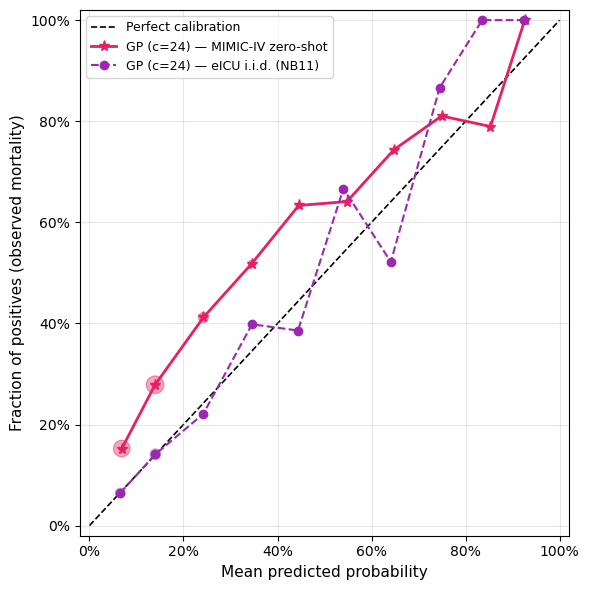

Saved: NB15_mimic_calibration.pdf/.png


In [7]:
## Cell 5 — Calibration Plot + Summary Figure

# Plan: Calibration curve for GP zero-shot on MIMIC-IV vs eICU references.
# Save to results/v2_bce/figures/NB15_mimic_calibration.pdf/.png

pred_df = pd.read_csv(DATA_PROC / 'mimic_gp_predictions.csv')
y_true  = pred_df['hospital_expire_flag'].values
gp_prob = pred_df['gp_prob'].values

# eICU reference calibration data from NB11
eicu_pred = pd.read_csv(DATA_PROC / 'gp_predictions_v2_bce.csv')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration', zorder=1)

# MIMIC-IV
c, a, s = calibration_bins(y_true, gp_prob)
ax.scatter(c, a, s=s/15, color='#E91E63', alpha=0.4, zorder=3)
ax.plot(c, a, color='#E91E63', marker='*', ls='-', lw=2.0, markersize=8,
        label='GP (c=24) — MIMIC-IV zero-shot', zorder=2)

# eICU i.i.d. reference
c2, a2, s2 = calibration_bins(eicu_pred['hospital_mortality'].values, eicu_pred['gp_prob'].values)
ax.scatter(c2, a2, s=s2/15, color='#9C27B0', alpha=0.3, zorder=3)
ax.plot(c2, a2, color='#9C27B0', marker='o', ls='--', lw=1.5, markersize=6,
        label='GP (c=24) — eICU i.i.d. (NB11)', zorder=2)

ax.set_xlabel('Mean predicted probability', fontsize=11)
ax.set_ylabel('Fraction of positives (observed mortality)', fontsize=11)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / 'NB15_mimic_calibration.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'NB15_mimic_calibration.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: NB15_mimic_calibration.pdf/.png')

### Findings — Cell 5: Calibration Plot

---

The calibration plot contrasts GP formula performance across the two evaluation settings and provides direct visual evidence for the prevalence-shift interpretation of the calibration degradation observed in Cell 4.

**eICU i.i.d. reference (purple, dashed).** The eICU curve oscillates around the diagonal throughout the 0–100% predicted probability range, consistent with the ECE of 0.013 reported in NB11. Some bin-level noise is visible at higher probabilities, reflecting smaller bin counts in the right tail of the eICU test set (n = 2,233). Overall, no systematic directional bias is present — the formula is well-calibrated in the population and prevalence on which it was trained.

**MIMIC-IV zero-shot (pink, solid).** The MIMIC-IV curve lies consistently above and to the left of the diagonal across the entire predicted probability range. At a predicted probability of approximately 7%, observed mortality in MIMIC-IV is approximately 16%; at 13% predicted, observed mortality is approximately 28%; at 25% predicted, approximately 41%. This pattern — wherein the observed outcome rate exceeds the predicted probability at every bin — is the visual signature of systematic under-prediction driven by prevalence anchoring. The formula was calibrated at eICU training prevalence (16.88%) and is applied to a population with 29.62% mortality; predicted scores are therefore systematically too low in absolute terms.

**Shape of miscalibration.** Crucially, the MIMIC-IV curve is monotonically increasing and approximately parallel to the diagonal, without crossings or inversions. This confirms that the miscalibration is a systematic shift (intercept-dominated) rather than a complex non-linear distortion of the probability scale. The curves converge near the high-probability end (≥80% predicted), where both datasets agree that patients with the highest formula scores face the highest observed mortality. This shape is directly amenable to a two-parameter post-hoc correction: a sigmoid recalibration (CMA-ES Platt scaling, as developed in NB13) applied to MIMIC-IV logit outputs would shift and rescale the predictions to match local prevalence, and would be expected to restore ECE to the 0.02–0.04 range demonstrated in NB13.

Saved to `results/v2_bce/figures/NB15_mimic_calibration.pdf/.png`.
